In [1]:
import sys 
sys.path.insert(
    0,
    "/raid0/homes/jkitzmann/dev/ITK-build-binarythinning/Wrapping/Generators/Python"
)
import itk

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Typesystem Boilerplate and Helper Functions

In [3]:
PixelType = itk.UC
Dimension = 3
ImageType = itk.Image[PixelType, Dimension]
LabelPixelType = itk.SS
LabelImageType = itk.Image[LabelPixelType, Dimension]
TubeType = itk.TubeSpatialObject[Dimension]
TubePointType = itk.TubeSpatialObjectPoint[Dimension]
PointSetType = itk.PointSet[itk.D, Dimension]

In [4]:
PixelType = itk.UC
Dimension = 3
ImageType = itk.Image[PixelType, Dimension]
FloatImageType = itk.Image[itk.F, Dimension]

def _to_xyz_list(points):
    """Normalize show_points into a list of (x, y, z) tuples.

    Accepts a single ITK index (or (x, y, z) sequence), or a list of them.
    """
    if points is None:
        return []

    # a bare (x, y, z) is one point; a list/tuple of those is many
    if not (isinstance(points, (list, tuple)) and not np.isscalar(points[0])):
        points = [points]

    return [(int(p[0]), int(p[1]), int(p[2])) for p in points]

def show_mip(image, show_points=None, cmap="gray"):
    ar = itk.array_view_from_image(image)

    points = _to_xyz_list(show_points)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(np.max(ar, axis=0), cmap=cmap)
    axes[0].set_title("Axial MIP")
    axes[0].axis("off")

    axes[1].imshow(np.max(ar, axis=1), cmap=cmap)
    axes[1].set_title("Coronal MIP")
    axes[1].axis("off")

    axes[2].imshow(np.max(ar, axis=2), cmap=cmap)
    axes[2].set_title("Sagittal MIP")
    axes[2].axis("off")

    # add points from list
    for ax, (col, row) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
        ax.autoscale(False)
        for point in points:
            ax.scatter(
                point[col],
                point[row],
                s=80,
                facecolors="none",
                edgecolors="red",
                linewidths=1.5,
            )

    plt.tight_layout()
    plt.show()

## Basic Tube Test

In [5]:
import numpy as np
import itk

class SyntheticTube:
    def __init__(self, size=(128, 128, 128)):
        self.size = size
        self.mask = np.zeros(size, dtype=np.uint8)
        self.points = (
            np.indices(size)
            .transpose(1, 2, 3, 0)
            .astype(np.float32)
        )
        self.branches = []
        self.pruned = []

    @staticmethod
    def _normalize(v):
        v = np.asarray(v, dtype=float)
        return v / np.linalg.norm(v)

    @staticmethod
    def _rotate(v, axis, angle):
        axis = SyntheticTube._normalize(axis)

        return (
            v * np.cos(angle)
            + np.cross(axis, v) * np.sin(angle)
            + axis * np.dot(axis, v) * (1.0 - np.cos(angle))
        )

    @staticmethod
    def _point_segment_distance(p, a, b):
        """Distance from point p to the segment a-b."""
        segment = b - a
        segment_length_sq = np.dot(
            segment,
            segment,
        )

        if segment_length_sq == 0:
            return np.linalg.norm(p - a)

        t = np.clip(
            np.dot(p - a, segment)
            / segment_length_sq,
            0.0,
            1.0,
        )

        return np.linalg.norm(
            p - (a + t * segment)
        )

    def _bifurcate(self, direction, normal, angle):
        """
        Two daughters, each `angle` away from the parent
        axis, both rotated about the same `normal`.

        Rotating about a single fixed normal is what keeps
        the whole tree in one plane: every daughter stays
        in the plane through the parent that is
        perpendicular to `normal`.
        """
        direction = self._normalize(direction)
        normal = self._normalize(normal)

        d1 = self._normalize(
            self._rotate(direction, normal, angle)
        )

        d2 = self._normalize(
            self._rotate(direction, normal, -angle)
        )

        return d1, d2

    def _clear_length(
        self,
        origin,
        direction,
        radius,
        length,
        ignore_ids,
        min_gap,
        step=0.25,
    ):
        """
        How far a tube of `radius` can run from `origin`
        along `direction` before it touches a branch that
        is not in `ignore_ids`.

        `ignore_ids` holds the branches a daughter is
        allowed to touch: its parent and its sibling, which
        by construction share the bifurcation point.

        Returns a length in [0, length].
        """
        n_steps = int(np.ceil(length / step))

        for i in range(n_steps + 1):
            s = min(i * step, length)
            p = origin + direction * s

            for branch in self.branches:
                if branch["branch_id"] in ignore_ids:
                    continue

                clearance = (
                    radius
                    + branch["radius"]
                    + min_gap
                )

                centerline = branch["centerline"]

                for a, b in zip(
                    centerline[:-1],
                    centerline[1:],
                ):
                    if (
                        self._point_segment_distance(p, a, b)
                        < clearance
                    ):
                        # Back off to the last clear sample.
                        return max(0.0, s - step)

        return length

    # ------------------------------------------------------------
    # Rasterization
    # ------------------------------------------------------------

    def add_tube(
        self,
        centerline,
        radius,
        generation,
        branch_id,
        parent_id=None,
    ):
        centerline = np.asarray(
            centerline,
            dtype=float,
        )

        length = np.sum(
            np.linalg.norm(
                np.diff(centerline, axis=0),
                axis=1,
            )
        )

        for p0, p1 in zip(
            centerline[:-1],
            centerline[1:],
        ):
            segment = p1 - p0
            segment_length_sq = np.dot(
                segment,
                segment,
            )

            if segment_length_sq == 0:
                continue

            # Only rasterize the voxels the segment can
            # reach, so cost scales with the tube and not
            # with the volume.
            lo = np.floor(
                np.minimum(p0, p1) - radius
            ).astype(int)

            hi = (
                np.ceil(
                    np.maximum(p0, p1) + radius
                ).astype(int)
                + 1
            )

            lo = np.clip(lo, 0, self.size)
            hi = np.clip(hi, 0, self.size)

            if np.any(hi <= lo):
                continue

            region = tuple(
                slice(l, h)
                for l, h in zip(lo, hi)
            )

            v = self.points[region] - p0

            t = np.sum(
                v * segment,
                axis=-1,
            ) / segment_length_sq

            t = np.clip(t, 0.0, 1.0)

            closest = (
                p0
                + t[..., None] * segment
            )

            distance = np.linalg.norm(
                self.points[region] - closest,
                axis=-1,
            )

            self.mask[region][distance <= radius] = 1

        self.branches.append(
            {
                "branch_id": branch_id,
                "parent_id": parent_id,
                "generation": generation,
                "centerline": centerline,
                "length": length,
                "radius": radius,
            }
        )

    # ------------------------------------------------------------
    # Recursive tree
    # ------------------------------------------------------------

    def _grow_branch(
        self,
        centerline,
        radius,
        generation,
        branch_id,
        parent_id,
        max_generations,
        branch_length,
        radius_scale,
        length_scale,
        angle,
        normal,
        min_gap,
        min_length_fraction,
    ):
        # Add current branch
        self.add_tube(
            centerline,
            radius,
            generation,
            branch_id,
            parent_id,
        )

        # Terminal branch
        if generation >= max_generations - 1:
            return

        # Direction of current branch
        direction = self._normalize(
            centerline[-1]
            - centerline[-2]
        )

        # Both daughters turn about the same normal, so the
        # tree never leaves its plane.
        d1, d2 = self._bifurcate(
            direction,
            normal,
            angle,
        )

        origin = centerline[-1]

        child_radius = radius * radius_scale
        child_length = branch_length * length_scale

        child_ids = (
            branch_id * 2 + 1,
            branch_id * 2 + 2,
        )

        for child_id, child_direction in zip(
            child_ids,
            (d1, d2),
        ):
            # A daughter may touch its parent and its
            # sibling -- they meet at the bifurcation.
            # Against everything else it is cut back to the
            # last point where it still clears the tree.
            usable_length = self._clear_length(
                origin=origin,
                direction=child_direction,
                radius=child_radius,
                length=child_length,
                ignore_ids={branch_id, *child_ids},
                min_gap=min_gap,
            )

            if (
                usable_length
                < min_length_fraction * child_length
            ):
                self.pruned.append(
                    {
                        "branch_id": child_id,
                        "generation": generation + 1,
                        "requested": child_length,
                        "available": usable_length,
                    }
                )
                continue

            child_centerline = np.array(
                [
                    origin,
                    origin
                    + child_direction
                    * usable_length / 2,
                    origin
                    + child_direction
                    * usable_length,
                ]
            )

            self._grow_branch(
                centerline=child_centerline,
                radius=child_radius,
                generation=generation + 1,
                branch_id=child_id,
                parent_id=branch_id,
                max_generations=max_generations,
                branch_length=branch_length * length_scale,
                radius_scale=radius_scale,
                length_scale=length_scale,
                angle=angle,
                normal=normal,
                min_gap=min_gap,
                min_length_fraction=min_length_fraction,
            )

    # ------------------------------------------------------------
    # Public interface
    # ------------------------------------------------------------

    def make_tree(
        self,
        centerline,
        radius=6,
        generations=5,
        branch_length=15,
        radius_scale=0.75,
        length_scale=0.75,
        bifurcation_angle=45.0,
        plane_normal=(1.0, 0.0, 0.0),
        min_gap=1.0,
        min_length_fraction=0.5,
    ):
        """
        Generate a planar binary airway tree.

        Every bifurcation is `bifurcation_angle` degrees:
        each daughter leaves the parent axis by that angle,
        so the two daughters are twice that apart.

        The tree is planar. Both daughters rotate about the
        same `plane_normal`, so every branch lies in the
        plane through the root that is perpendicular to it.
        `plane_normal` is orthogonalized against the root
        direction, and must not be parallel to it.

        Branches never overlap. A planar tree with a fixed
        bifurcation angle collides from about generation 5
        on -- the inner daughters of the two sides converge
        back onto the trunk axis -- so each daughter is cut
        back to the last length at which its tube still
        clears every branch other than its parent and its
        sibling, by `min_gap` voxels. A daughter left with
        less than `min_length_fraction` of its requested
        length is dropped instead, and recorded in
        `self.pruned`.

        The tree therefore has at most

            1 + 2 + 4 + ... = 2**generations - 1

        branches, and fewer wherever the plane ran out of
        room.
        """
        centerline = np.asarray(
            centerline,
            dtype=float,
        )

        root_direction = self._normalize(
            centerline[-1]
            - centerline[-2]
        )

        normal = np.asarray(
            plane_normal,
            dtype=float,
        )

        normal -= (
            np.dot(normal, root_direction)
            * root_direction
        )

        if np.linalg.norm(normal) < 1e-6:
            raise ValueError(
                "plane_normal is parallel to the root "
                "direction; the bifurcation plane is "
                "undefined."
            )

        self._grow_branch(
            centerline=centerline,
            radius=radius,
            generation=0,
            branch_id=0,
            parent_id=None,
            max_generations=generations,
            branch_length=branch_length,
            radius_scale=radius_scale,
            length_scale=length_scale,
            angle=np.deg2rad(bifurcation_angle),
            normal=self._normalize(normal),
            min_gap=min_gap,
            min_length_fraction=min_length_fraction,
        )

        return self

    # ------------------------------------------------------------
    # Output
    # ------------------------------------------------------------

    def to_numpy(self):
        return self.mask

    def to_itk(self):
        return itk.image_from_array(self.mask)

    # ------------------------------------------------------------
    # Reporting
    # ------------------------------------------------------------

    def check_overlap(self, step=0.25):
        """
        Every pair of branches that is not parent/child or
        sibling/sibling, and whose tubes come closer than
        the sum of their radii.

        Returns a list of
        (branch_id, branch_id, distance, sum of radii).
        """
        collisions = []

        for i, a in enumerate(self.branches):
            for b in self.branches[i + 1:]:
                if (
                    a["parent_id"] == b["branch_id"]
                    or b["parent_id"] == a["branch_id"]
                    or a["parent_id"] == b["parent_id"]
                ):
                    continue

                clearance = a["radius"] + b["radius"]

                closest = np.inf

                for p in self._sample(a["centerline"], step):
                    for q0, q1 in zip(
                        b["centerline"][:-1],
                        b["centerline"][1:],
                    ):
                        closest = min(
                            closest,
                            self._point_segment_distance(
                                p, q0, q1
                            ),
                        )

                if closest < clearance:
                    collisions.append(
                        (
                            a["branch_id"],
                            b["branch_id"],
                            closest,
                            clearance,
                        )
                    )

        return collisions

    @staticmethod
    def _sample(centerline, step):
        for a, b in zip(
            centerline[:-1],
            centerline[1:],
        ):
            length = np.linalg.norm(b - a)

            for i in range(
                int(np.ceil(length / step)) + 1
            ):
                yield a + (b - a) * min(
                    i * step / length,
                    1.0,
                )

    def report_branches(self):
        for branch in self.branches:
            print(
                f"Branch {branch['branch_id']:2d} | "
                f"Generation {branch['generation']} | "
                f"Length {branch['length']:.2f} | "
                f"Radius {branch['radius']:.2f}"
            )

        for branch in self.pruned:
            print(
                f"Pruned {branch['branch_id']:2d} | "
                f"Generation {branch['generation']} | "
                f"Requested {branch['requested']:.2f} | "
                f"Available {branch['available']:.2f}"
            )

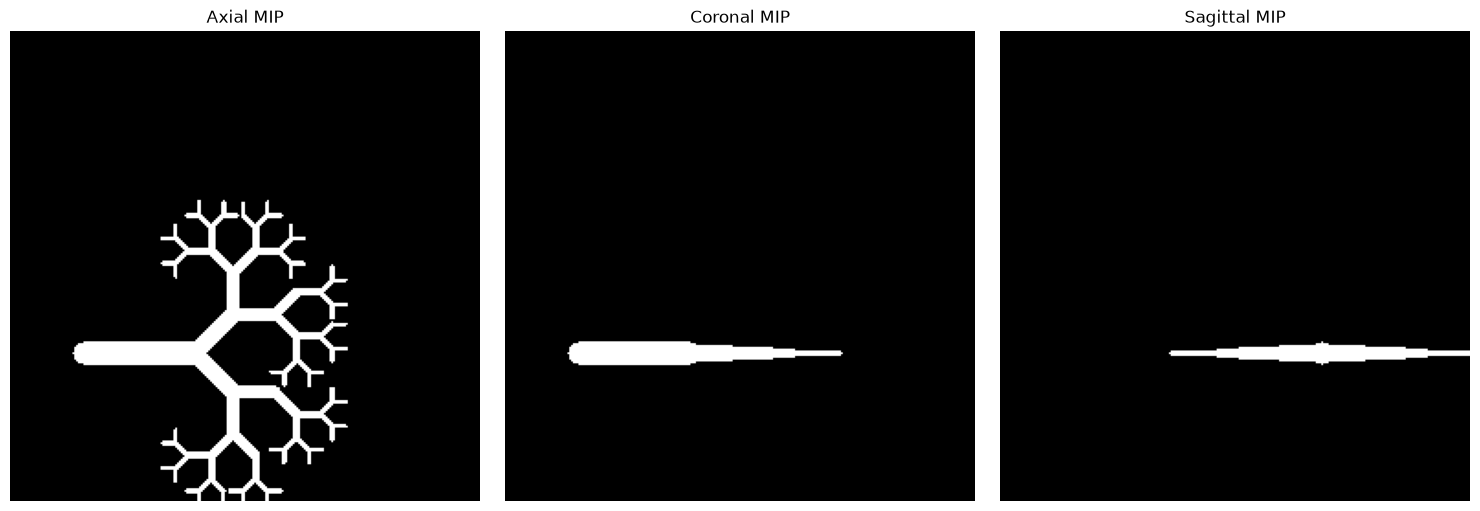

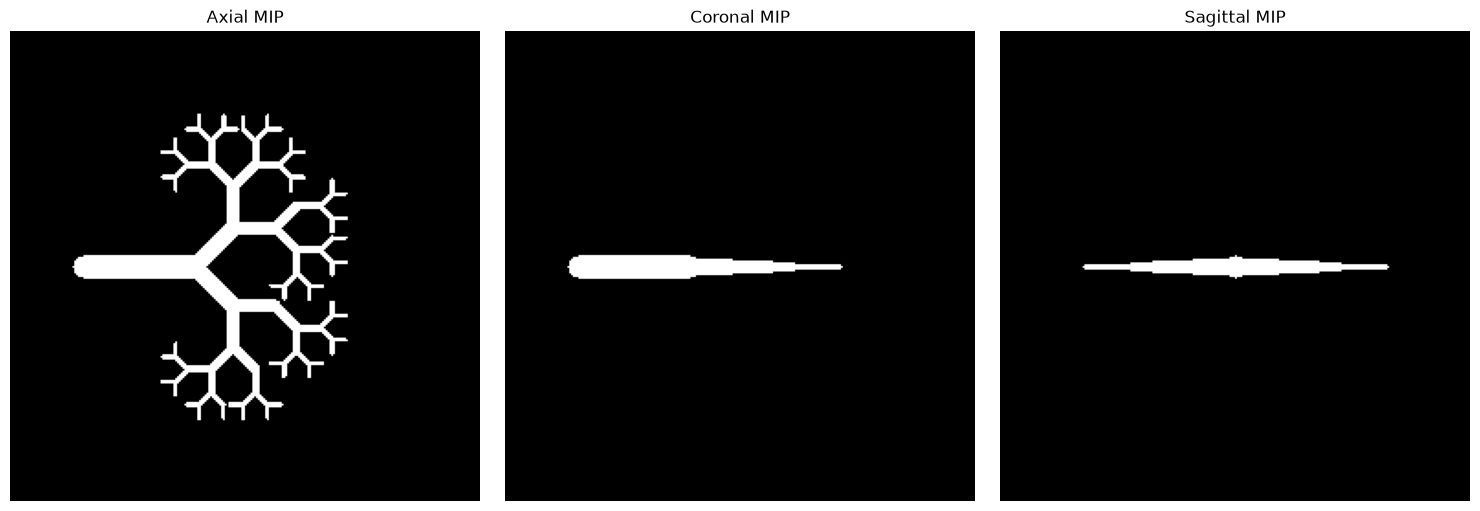

In [6]:
fixed_airway = SyntheticTube(
    size=(256, 256, 256)
)
fixed_airway.make_tree(
    centerline=[
        (128, 128, 40),
        (128, 128, 70),
        (128, 128, 100),
    ],
    radius=6,
    generations=7,
    branch_length=40,
    bifurcation_angle=45.0,
    plane_normal=(1.0, 0.0, 0.0),
)

moving_airway = SyntheticTube(
    size=(256, 256, 256)
)
moving_airway.make_tree(
    centerline=[
        (175, 175, 40),
        (175, 175, 70),
        (175, 175, 100),
    ],
    radius=6,
    generations=7,
    branch_length=40,
    bifurcation_angle=45.0,
    plane_normal=(1.0, 0.0, 0.0),
)

moving_image = moving_airway.to_itk()
fixed_image = fixed_airway.to_itk()

show_mip(moving_image)
show_mip(fixed_image)


## Deformable Registration and Analysis Pipeline

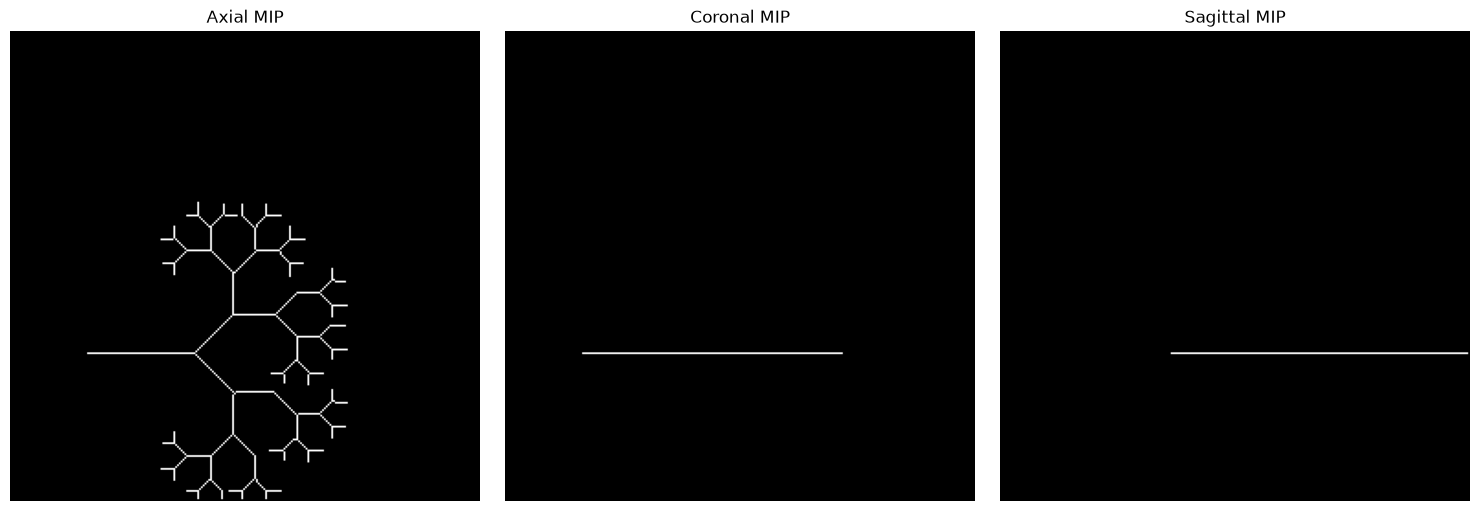

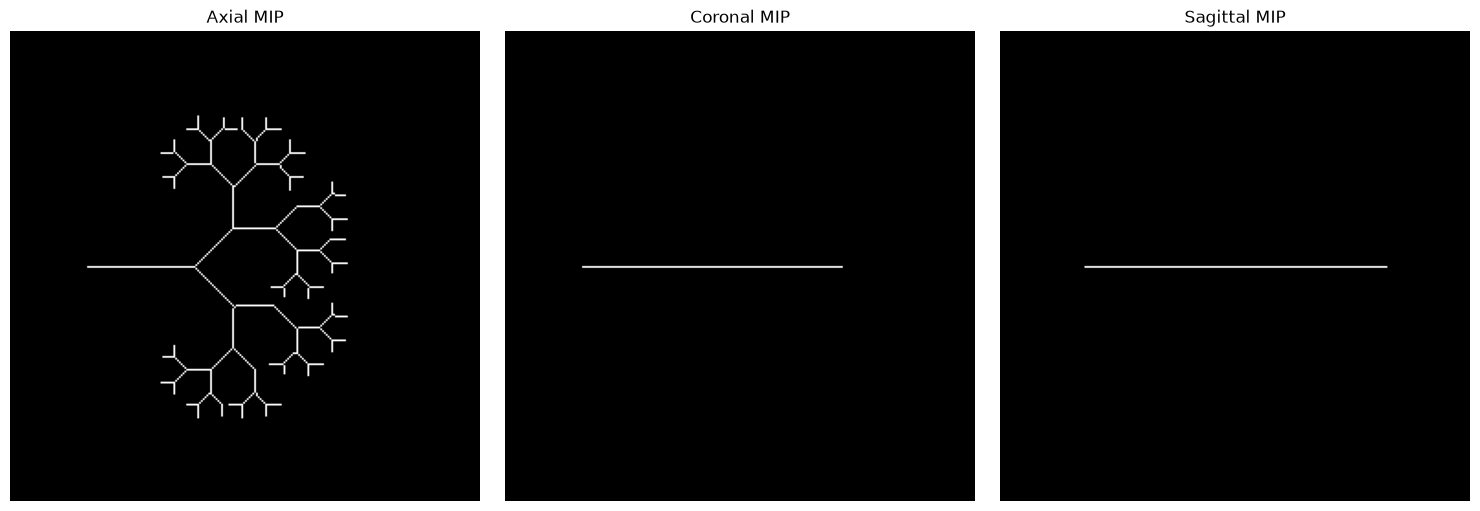

In [7]:
SkeletonizeAirwayType = itk.SkeletonizeAirway[ImageType]

skeletonizeAirwayPrediction = SkeletonizeAirwayType.New()
skeletonizeAirwayPrediction.SetInput(moving_image)
skeletonizeAirwayPrediction.Update()
moving_skeleton = skeletonizeAirwayPrediction.GetOutput()
show_mip(moving_skeleton)

skeletonizeAirwayGroundTruth = SkeletonizeAirwayType.New()
skeletonizeAirwayGroundTruth.SetInput(fixed_image)
skeletonizeAirwayGroundTruth.Update()
fixed_skeleton = skeletonizeAirwayGroundTruth.GetOutput()
show_mip(fixed_skeleton)

## Initial Labeling

widest index: [43, 175, 175]


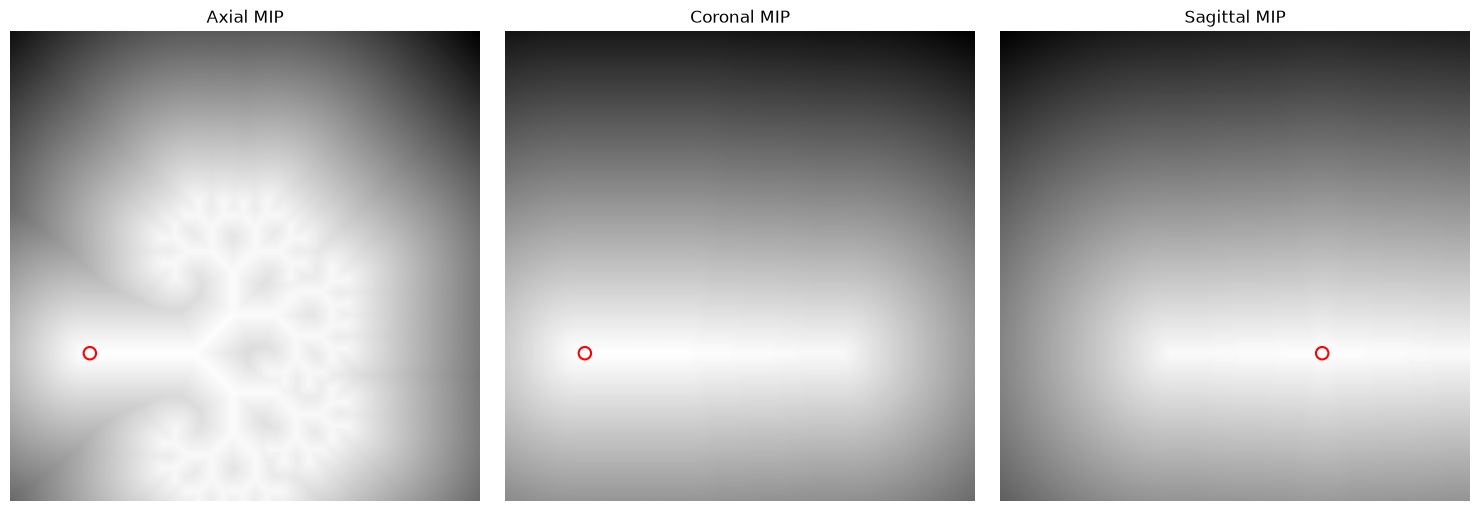

widest index: [43, 128, 128]


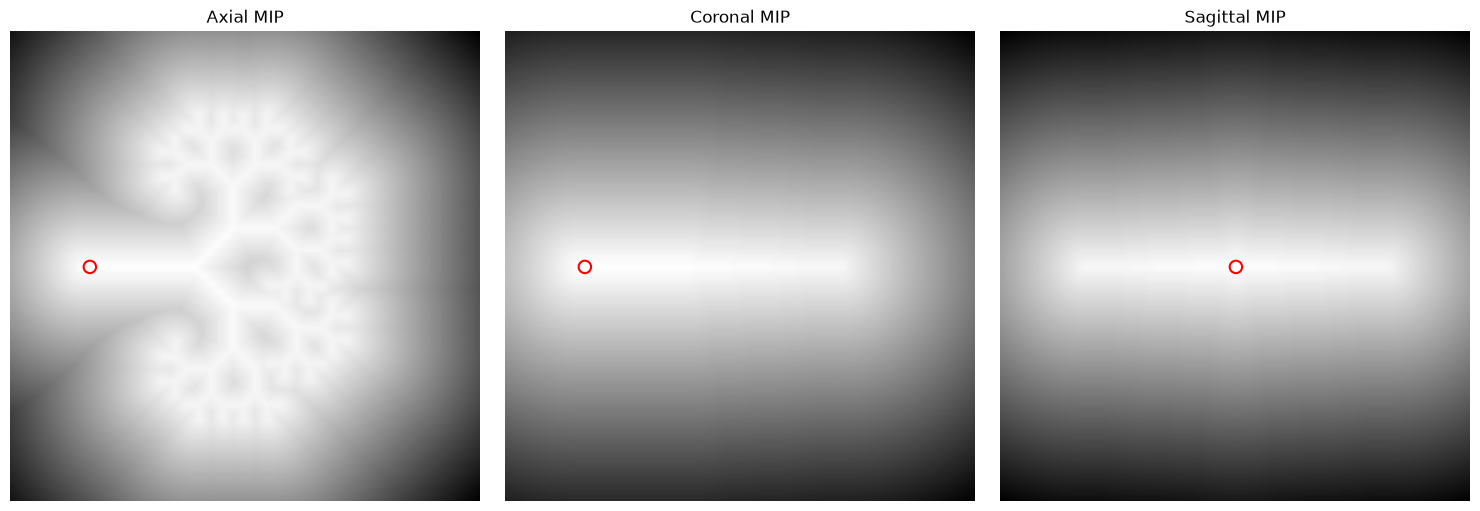

In [8]:
LabelPixelType = itk.SS
LabelImageType = itk.Image[LabelPixelType, Dimension]

SkeletonLabelingType = itk.SkeletonLabeling[ImageType, LabelImageType]

skeletonLabelingPrediction = SkeletonLabelingType.New()
skeletonLabelingPrediction.SetMaskImage(moving_image)
skeletonLabelingPrediction.SetSkeletonImage(moving_skeleton)
skeletonLabelingPrediction.SetSensitivityMultiplier(1.0)
skeletonLabelingPrediction.Update()
branchLabelsImagePrediction = skeletonLabelingPrediction.GetBranchLabelsImage()
generationLabelsImagePrediction = skeletonLabelingPrediction.GetGenerationLabelsImage()
distanceMapImagePrediction = skeletonLabelingPrediction.GetDistanceMapImage()
widestIndexPrediction = skeletonLabelingPrediction.GetWidestIndex()

print("widest index:", list(widestIndexPrediction))
show_mip(distanceMapImagePrediction, show_points=widestIndexPrediction)

skeletonLabelingGroundTruth = SkeletonLabelingType.New()
skeletonLabelingGroundTruth.SetMaskImage(fixed_image)
skeletonLabelingGroundTruth.SetSkeletonImage(fixed_skeleton)
skeletonLabelingGroundTruth.SetSensitivityMultiplier(1.0)
skeletonLabelingGroundTruth.Update()
branchLabelsImageGroundTruth = skeletonLabelingGroundTruth.GetBranchLabelsImage()
generationLabelsImageGroundTruth = skeletonLabelingGroundTruth.GetGenerationLabelsImage()
distanceMapImageGroundTruth = skeletonLabelingGroundTruth.GetDistanceMapImage()
widestIndexGroundTruth = skeletonLabelingGroundTruth.GetWidestIndex()

print("widest index:", list(widestIndexGroundTruth))
show_mip(distanceMapImageGroundTruth, show_points=widestIndexGroundTruth)

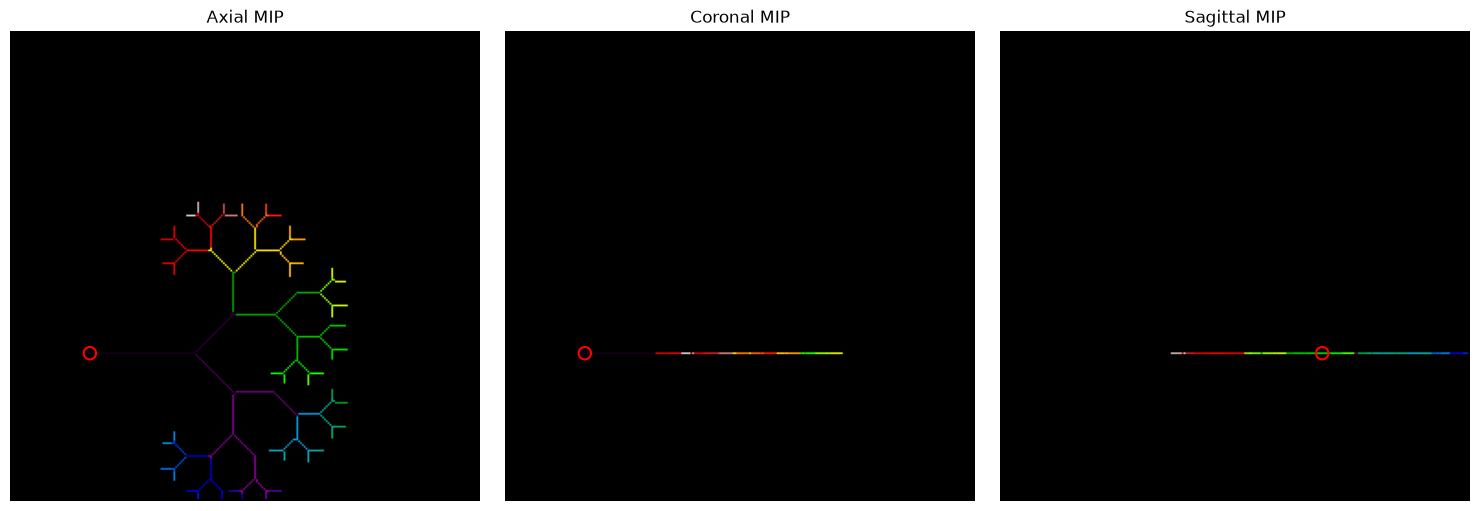

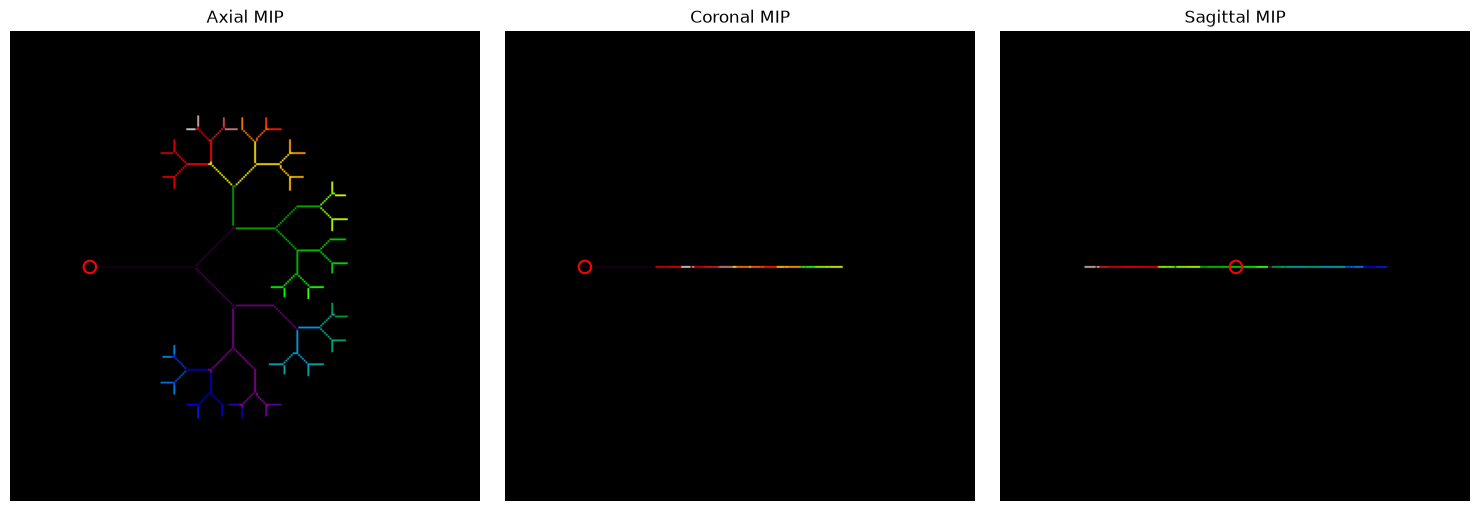

In [9]:
branch_labels_prediction = itk.array_view_from_image(branchLabelsImagePrediction)
show_mip(branchLabelsImagePrediction, show_points=widestIndexPrediction, cmap="nipy_spectral")

branch_labels_groundTruth = itk.array_view_from_image(branchLabelsImageGroundTruth)
show_mip(branchLabelsImageGroundTruth, show_points=widestIndexGroundTruth, cmap="nipy_spectral")


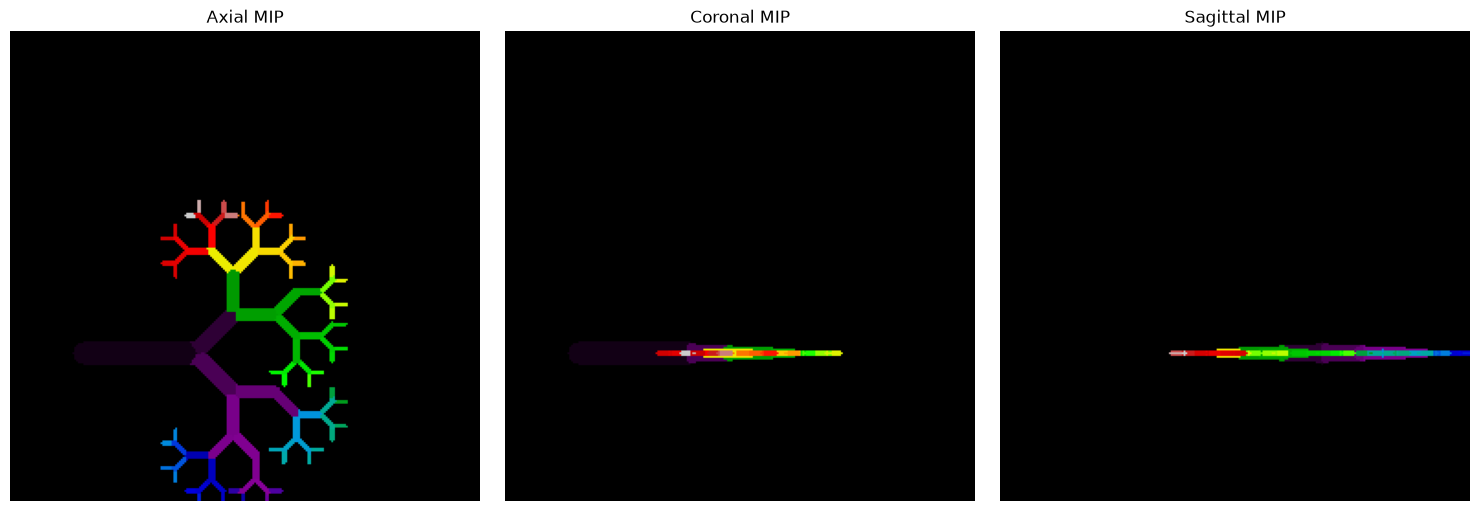

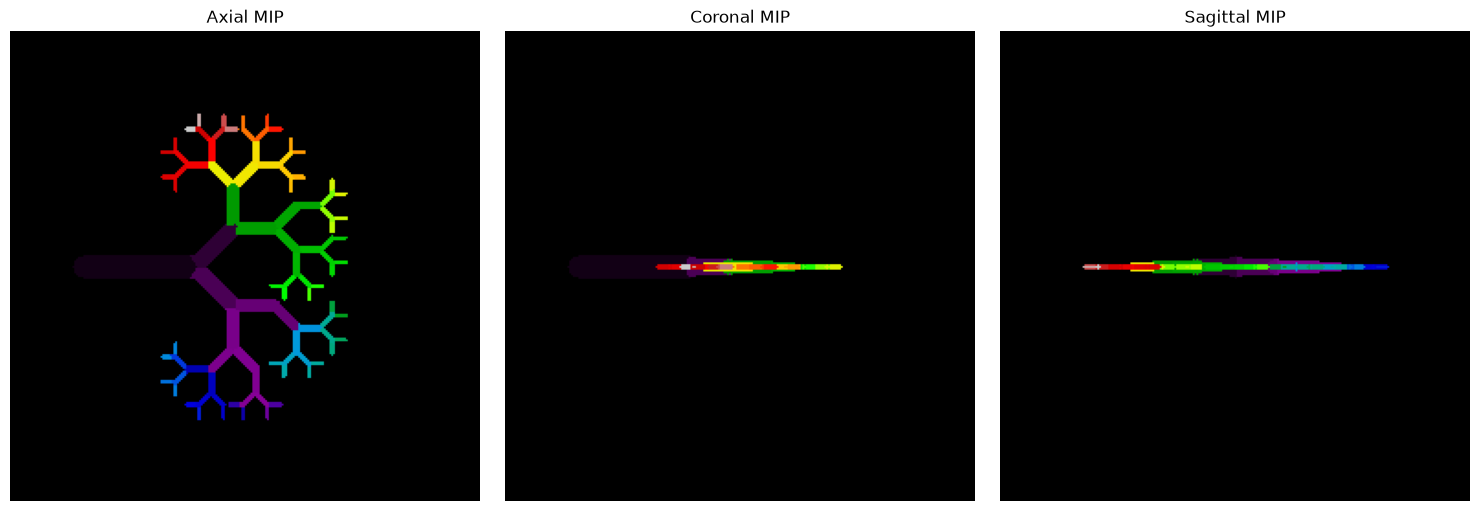

In [10]:
ProjectAirwayType = itk.ProjectAirway[ImageType, LabelImageType]

projectAirwayPrediction = ProjectAirwayType.New()
projectAirwayPrediction.SetSegmentationImage(moving_image)
projectAirwayPrediction.SetBranchSkeletonLabelsImage(branchLabelsImagePrediction)
projectAirwayPrediction.SetGenerationSkeletonLabelsImage(generationLabelsImagePrediction)
projectAirwayPrediction.SetNumberOfNeighbors(5)
projectAirwayPrediction.Update()
projectedBranchLabelsImagePrediction = projectAirwayPrediction.GetBranchLabelsImage()
show_mip(projectedBranchLabelsImagePrediction, cmap="nipy_spectral")

projectAirwayGroundTruth = ProjectAirwayType.New()
projectAirwayGroundTruth.SetSegmentationImage(fixed_image)
projectAirwayGroundTruth.SetBranchSkeletonLabelsImage(branchLabelsImageGroundTruth)
projectAirwayGroundTruth.SetGenerationSkeletonLabelsImage(generationLabelsImageGroundTruth)
projectAirwayGroundTruth.SetNumberOfNeighbors(5)
projectAirwayGroundTruth.Update()
projectedBranchLabelsImageGroundTruth = projectAirwayGroundTruth.GetBranchLabelsImage()
show_mip(projectedBranchLabelsImageGroundTruth, cmap="nipy_spectral")

moving_image = projectedBranchLabelsImagePrediction
fixed_image = projectedBranchLabelsImageGroundTruth

## Get Branch Points

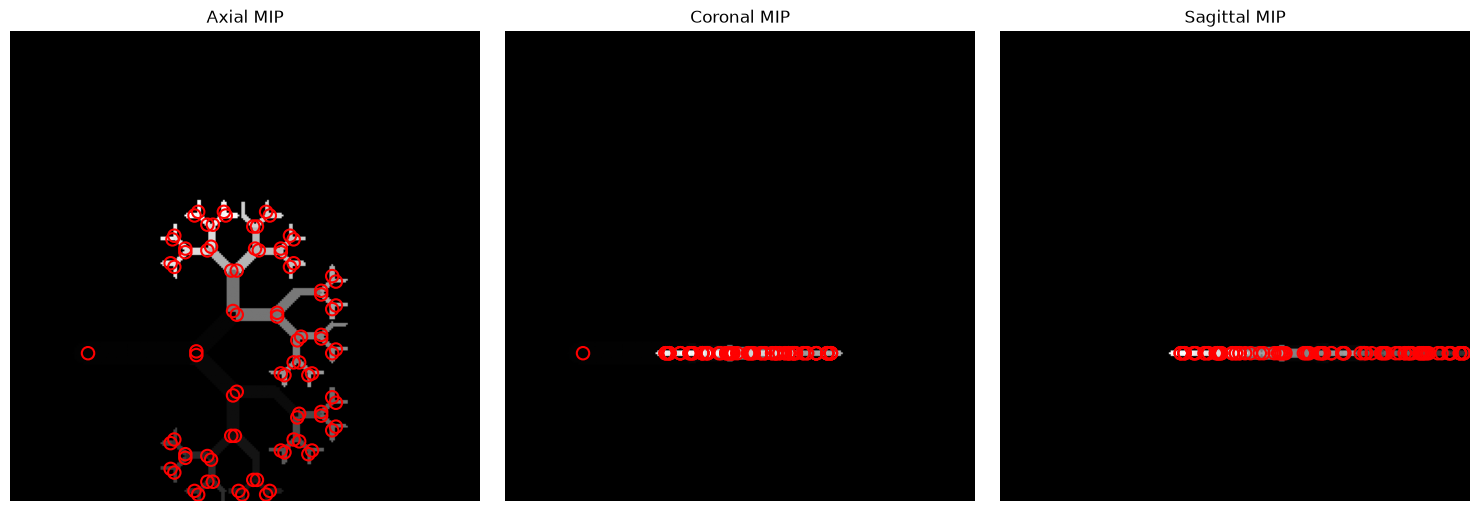

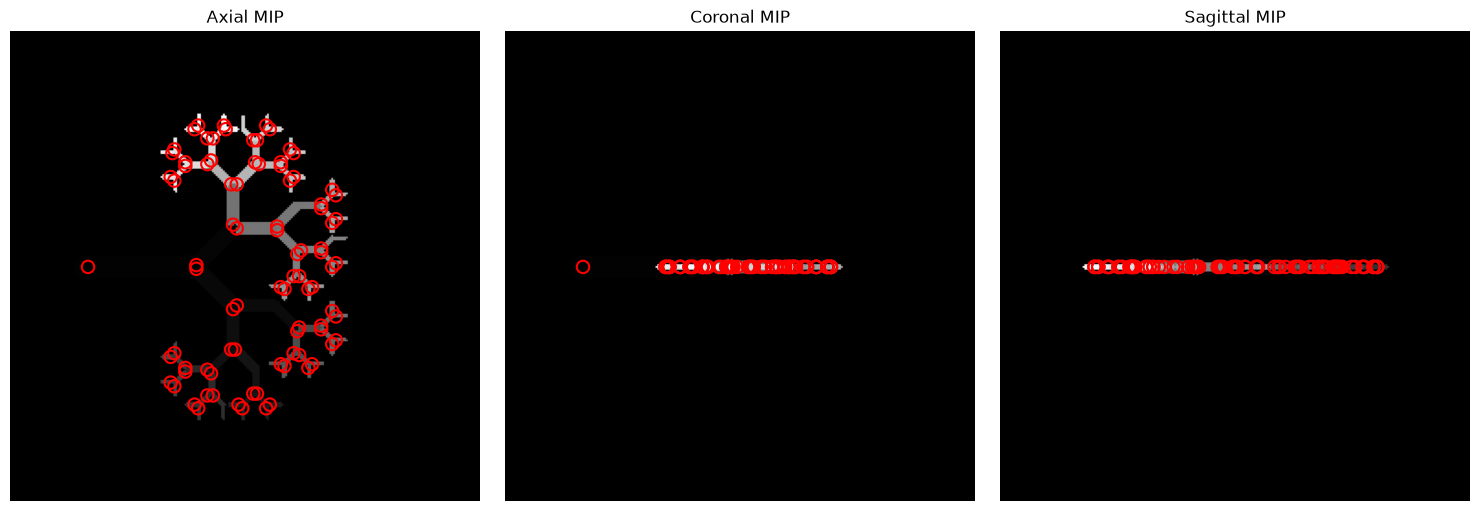

In [11]:
n_branches_prediction = skeletonLabelingPrediction.GetNumberOfBranches()
branch_ids_prediction = range(1, n_branches_prediction + 1)
branch_origins_prediction = [skeletonLabelingPrediction.GetBranchOriginIndex(i) for i in branch_ids_prediction]

n_branches_groundTruth = skeletonLabelingGroundTruth.GetNumberOfBranches()
branch_ids_groundTruth = range(1, n_branches_groundTruth + 1)
branch_origins_groundTruth = [skeletonLabelingGroundTruth.GetBranchOriginIndex(i) for i in branch_ids_groundTruth]

show_mip(moving_image, branch_origins_prediction)
show_mip(fixed_image, branch_origins_groundTruth)

In [12]:
def convert_points(point_list):
    point_set = PointSetType.New()
    point_set_points = point_set.GetPoints()
    for idx, point in enumerate(point_list):
        point_output = itk.Point[itk.D, Dimension]()
        point_output[0] = point[0]
        point_output[1] = point[1]
        point_output[2] = point[2]
        
        point_set_points.InsertElement(idx, point_output)

    return point_set

fixed_points = convert_points(branch_origins_groundTruth)
moving_points = convert_points(branch_origins_prediction)

fixed_points

<itk.itkPointSetPython.itkPointSetD3; proxy of <Swig Object of type 'itkPointSetD3 *' at 0x7f4f0091e730> >

In [13]:
RigidlyAlignAirwaysType = itk.RigidlyAlignAirways[PointSetType]
rigidlyAlignAirways = RigidlyAlignAirwaysType.New()
rigidlyAlignAirways.SetFixedPointSet(fixed_points)
rigidlyAlignAirways.SetMovingPointSet(moving_points)
rigidlyAlignAirways.Update()
transform = rigidlyAlignAirways.GetTransform()
print(transform.GetMatrix())

itkMatrixD33 ([[0.9999999999875121, -2.647101764793872e-07, -4.990556674208561e-06], [2.647085447619043e-07, 0.9999999999999115, -3.269616741476716e-07], [4.990556760758202e-06, 3.269603531005938e-07, 0.9999999999874938]])Initial parameters: [3.2696035310059964e-7, -0.000004990556760779185, 2.647101764794044e-7, 0.018091605141462165, -47.00886037895346, -47.00519513154688]

Identity metric: [0.019962187237551096, 0.01988485715593577, 0.019884247569581556, 0.0198502760544223, 0.01985217985456385, 0.019846760782863904, 0.019844250758843714, 0.019824509024308688, 0.019822030373850375, 0.019813437750272486, 0.01981158057643105, 0.019832652644336087, 0.019829550050492566, 0.01985984456192069, 0.019856697196397172, 0.019851781957714833, 0.0198555864533728, 0.019862982038534354, 0.019859819874347335, 0.019875483824116177, 0.019874873962360286, 0.01988335778563212, 0.01988016188076673, 0.019885657365625597, 0.019887633793291257, 0.01980470360607916, 0.019805315040361236, 0.019800187396938087, 

In [30]:
aligned = itk.resample_image_filter(
    moving_airway.to_itk(),
    transform=transform.GetInverseTransform(),
    use_reference_image=True,
    reference_image=fixed_image,
    interpolator = itk.NearestNeighborInterpolateImageFunction.New(moving_airway.to_itk()),
    default_pixel_value=0
)

In [31]:
transform = rigidlyAlignAirways.GetTransform()
aligned_points_list = []

for i in range(moving_points.GetNumberOfPoints()):
    point = moving_points.GetPoint(i)
    aligned_point = transform.TransformPoint(point)
    aligned_points_list.append(aligned_point)

aligned_points = convert_points(aligned_points_list)

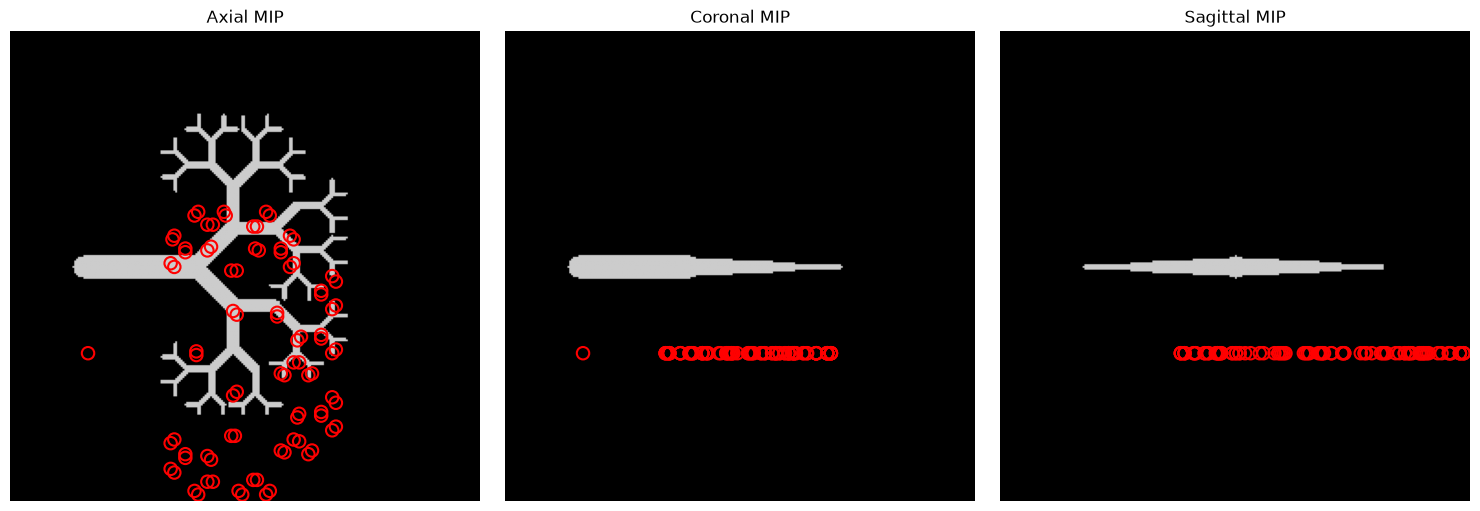

<class 'itk.itkPointSetPython.itkPointSetD3'>


In [32]:
show_mip(aligned, show_points=branch_origins_prediction, cmap='nipy_spectral')
print(type(aligned_points))

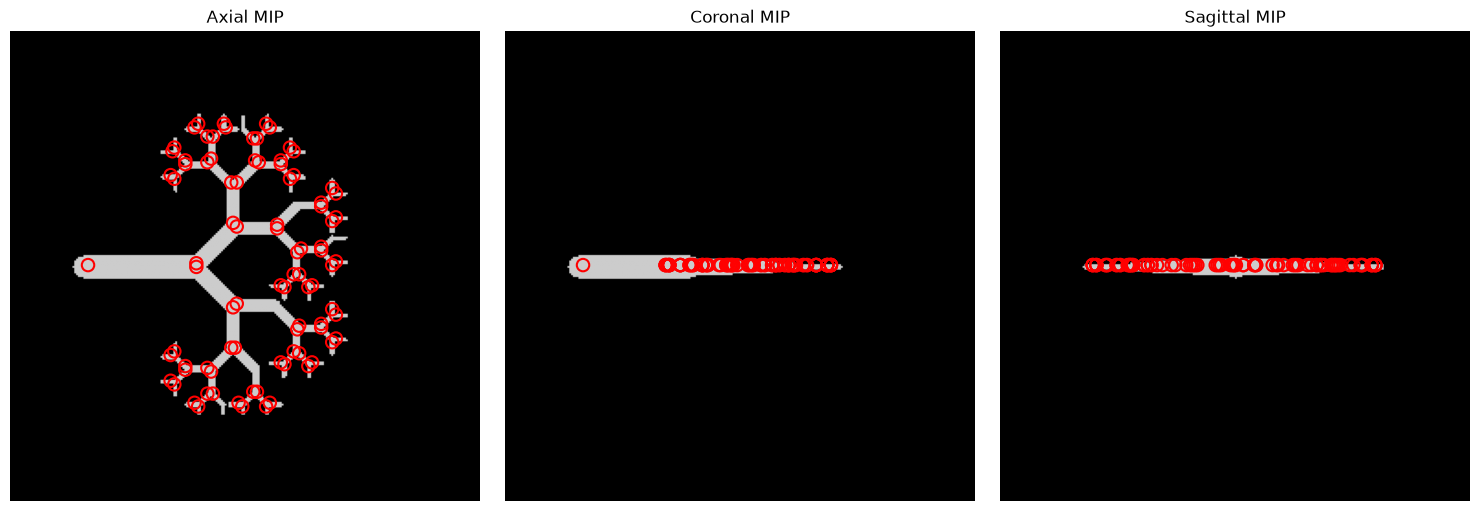

<class 'itk.itkPointSetPython.itkPointSetD3'>


In [33]:
show_mip(aligned, show_points=aligned_points_list, cmap='nipy_spectral')
print(type(aligned_points))

## Skeletonized Resampled

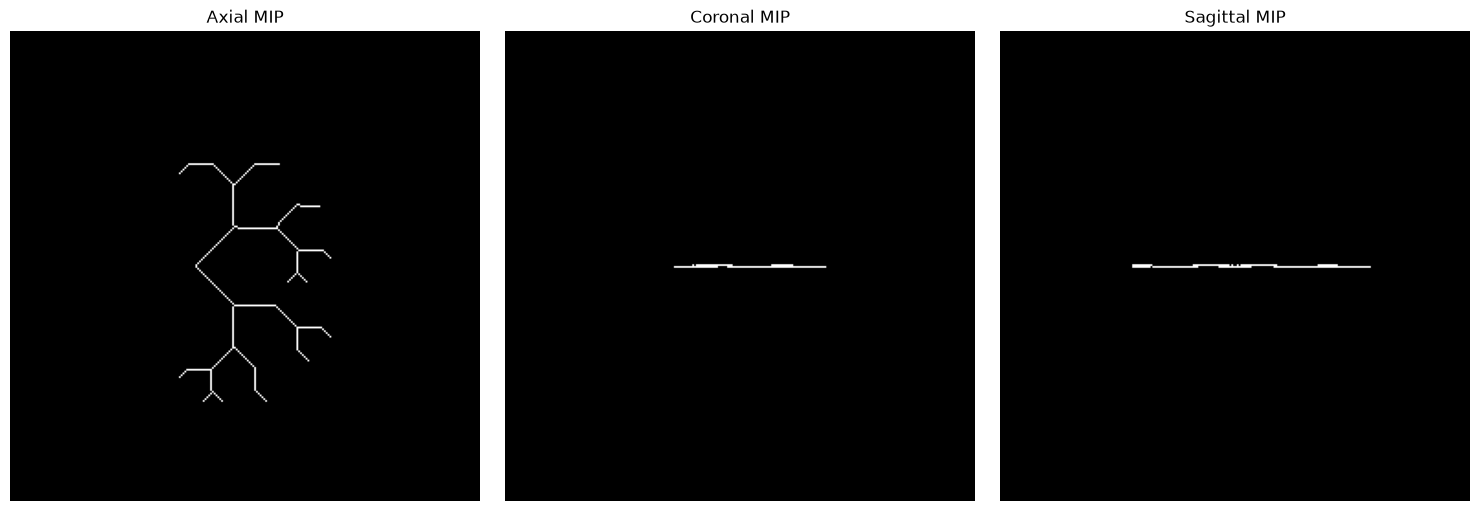

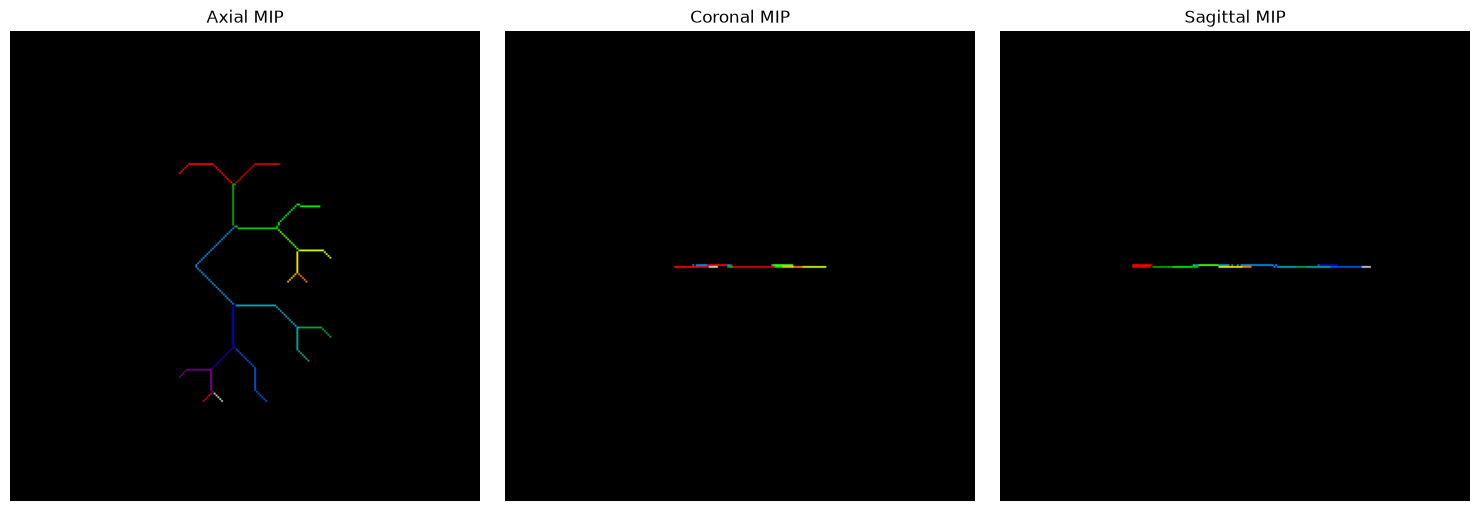

In [27]:
skeletonizeAirwayAligned = SkeletonizeAirwayType.New()
skeletonizeAirwayAligned.SetInput(aligned)
skeletonizeAirwayAligned.Update()
aligned_skeleton = skeletonizeAirwayAligned.GetOutput()
show_mip(aligned_skeleton)

skeletonLabelingAligned = SkeletonLabelingType.New()
skeletonLabelingAligned.SetMaskImage(moving_airway.to_itk())
skeletonLabelingAligned.SetSkeletonImage(aligned_skeleton)
skeletonLabelingAligned.SetSensitivityMultiplier(1.0)
skeletonLabelingAligned.Update()
show_mip(skeletonLabelingAligned.GetBranchLabelsImage(), cmap='nipy_spectral')

## Project terminal nonterminal to full images

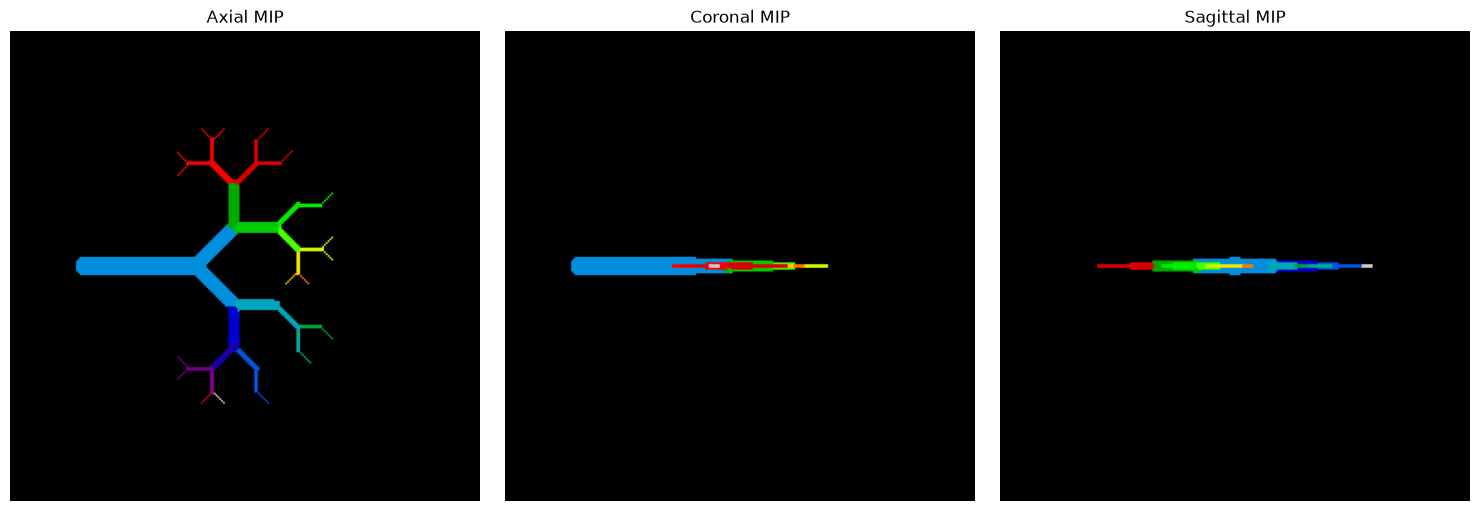

In [20]:
projectAirwayAligned = ProjectAirwayType.New()
projectAirwayAligned.SetSegmentationImage(aligned)
projectAirwayAligned.SetBranchSkeletonLabelsImage(skeletonLabelingAligned.GetBranchLabelsImage())
projectAirwayAligned.SetGenerationSkeletonLabelsImage(skeletonLabelingAligned.GetGenerationLabelsImage())
projectAirwayAligned.SetNumberOfNeighbors(5)
projectAirwayAligned.Update()
show_mip(projectAirwayAligned.GetBranchLabelsImage(), cmap="nipy_spectral")

In [21]:
def terminal_nonterminal(image, labeling_class, is_terminal):
    array = itk.array_from_image(image).copy()

    for index in np.ndindex(array.shape):
        value = array[index]

        if value == 0:
            continue

        if labeling_class.IsBranchTerminal(int(value)) != is_terminal:
            array[index] = 0

    output = itk.image_from_array(array)
    output.CopyInformation(image)

    return output

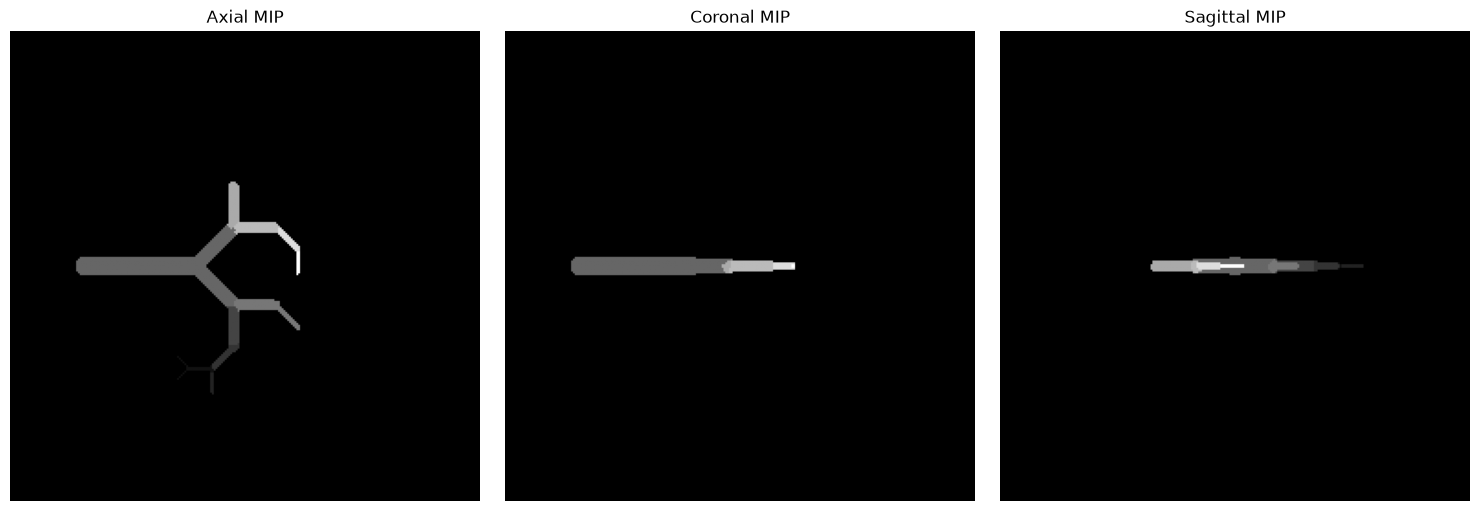

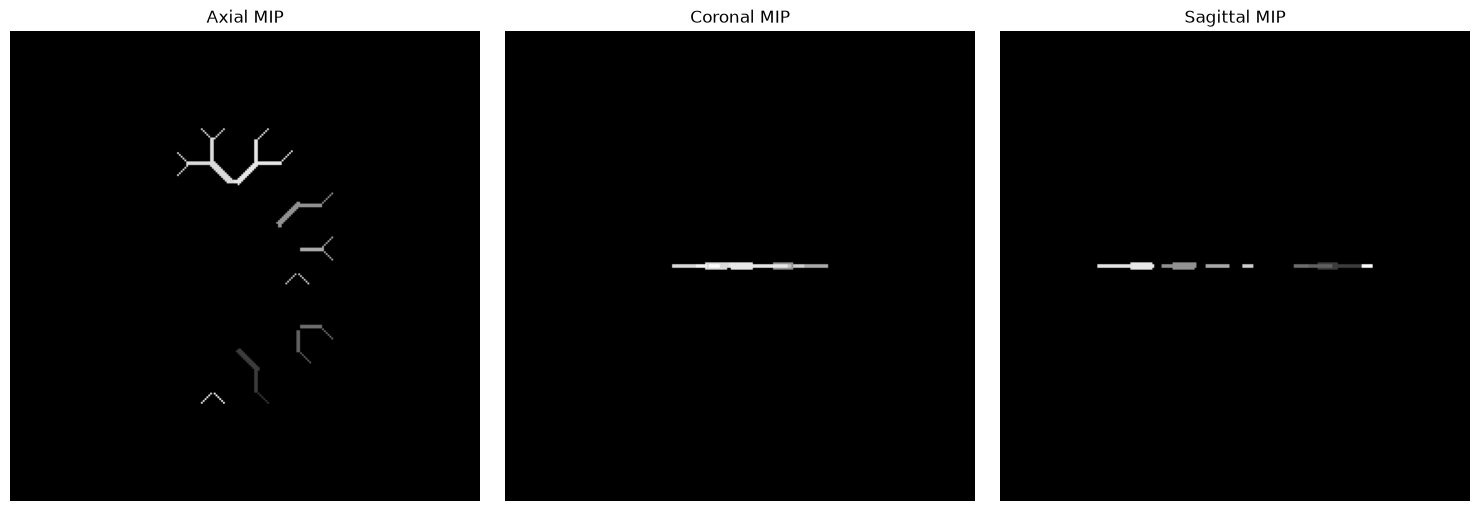

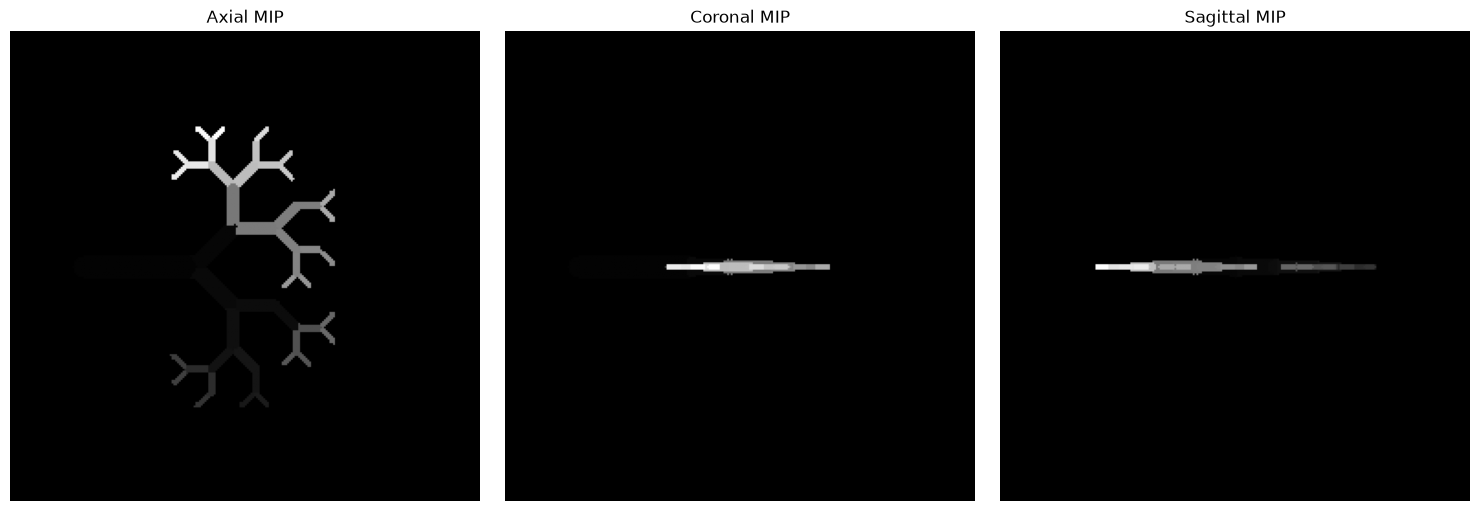

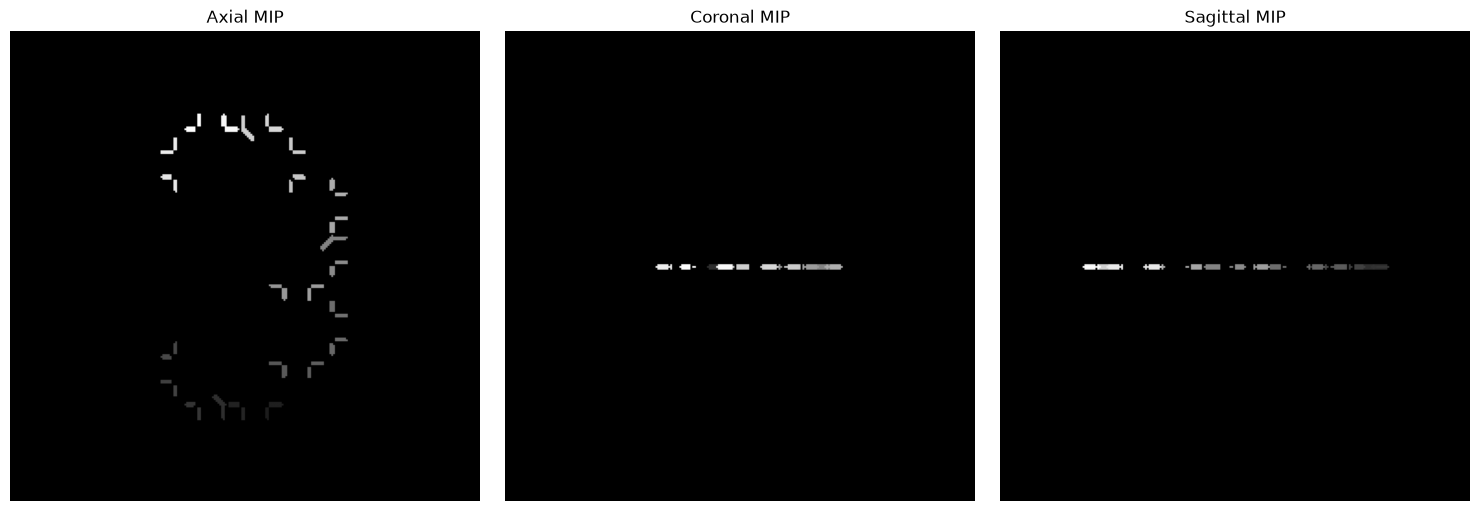

In [22]:
nonterminal_aligned = terminal_nonterminal(projectAirwayAligned.GetBranchLabelsImage(), skeletonLabelingAligned, False)
show_mip(nonterminal_aligned)
terminal_aligned = terminal_nonterminal(projectAirwayAligned.GetBranchLabelsImage(), skeletonLabelingAligned, True)
show_mip(terminal_aligned)

nonterminal_fixed = terminal_nonterminal(projectAirwayGroundTruth.GetBranchLabelsImage(), skeletonLabelingGroundTruth, False)
show_mip(nonterminal_fixed)
terminal_fixed = terminal_nonterminal(projectAirwayGroundTruth.GetBranchLabelsImage(), skeletonLabelingGroundTruth, True)
show_mip(terminal_fixed)


## Rigidly Register The Fixed and Aligned Nonterminal Images

In [23]:
transform = rigidlyAlignAirways.GetTransform().GetInverseTransform()

aligned_points = np.empty_like(moving_points, dtype=float)

for i, point in enumerate(movingdd_points):
    aligned_points[i] = transform.TransformPoint(tuple(point))

NameError: name 'movingdd_points' is not defined

In [ ]:
transform = rigidlyAlignAirways.GetTransform().GetInverseTransform()

point = moving_points[0]

print("point:", point)
print("type:", type(point))

result = transform.TransformPoint(tuple(point))

print("result:", result)
print("result type:", type(result))